# Problema:
## Imagina que eres un investigador médico que recopila datos para un estudio. Has recopilado datos sobre un conjunto de pacientes, todos ellos con la misma enfermedad. Durante su tratamiento, cada paciente ha respondido a uno de los 5 medicamentos, el fármaco A, el fármaco B, el fármaco c, el fármaco X y el Y. 

## Parte de tu trabajo consiste en construir un modelo para averiguar qué medicamento podría ser apropiado para un futuro paciente con la misma enfermedad. Los conjuntos de características de este conjunto de datos son la edad, el sexo, la presión arterial y el colesterol de los pacientes, y el objetivo es estudiar el fármaco al que respondió cada paciente. 

## Se trata de un ejemplo de clasificación multiclase, y se puede utilizar la parte de entrenamiento del conjunto de datos para construir un árbol de decisión, y luego utilizarlo para predecir la clase de un paciente desconocido, o para prescribirlo a un nuevo paciente.

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot
import warnings
import numpy as np

warnings.filterwarnings("ignore")

#Todo lo mantengo en la misma carpeta, pero este codigo se utilizaria para cambiar la ubicación del directorio utilizado
# import os
# os.getcwd()
# os.chdir('C:\\Users\\saulim\\Documents\\Python Proyectos\\Jupyter notebook\\3- Aprendizaje de máquina supervisado\\M24- Ensambles Consenso y Potenciación')

In [4]:
BD_drugs = pd.read_csv("drugs.csv")
BD_drugs.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


## Cargue la base de datos “drugs.csv” en Python e investigue cómo convertir las variables predictoras cualitativas de esta base a una escala numérica mediante la instrucción “preprocessing.LabelEncoder()”.
## Por ejemplo, si una variable tiene 3 posibles categorías, deberá cambiar sus resultados a 0, 1 o 2.

In [7]:
# Columnas de entradas
feature_cols = ["Age","Sex", "BP", "Cholesterol", "Na_to_K"]

X = BD_drugs[feature_cols].values

#Columnas de salidas
y = BD_drugs.Drug

#Preprosesamiento para generar El label encoder
from sklearn import preprocessing

Cod_Sex = preprocessing.LabelEncoder()
Cod_BP = preprocessing.LabelEncoder()
Cod_Cholesterol = preprocessing.LabelEncoder()

Cod_Sex.fit(["M", "F"])                # 1 = Male , 0= Female 
Cod_BP.fit(["NORMAL", "LOW", "HIGH"])                 # 2= Normal, 1=LOW, 0=High
Cod_Cholesterol.fit(["NORMAL", "HIGH"])        # 1= Normal, 0=High

X[:,1] = Cod_Sex.transform(X[:,1])
X[:,2] = Cod_BP.transform(X[:,2])
X[:,3] = Cod_Cholesterol.transform(X[:,3])

X[0:10]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043],
       [22, 0, 2, 0, 8.607],
       [49, 0, 2, 0, 16.275],
       [41, 1, 1, 0, 11.037],
       [60, 1, 2, 0, 15.171],
       [43, 1, 1, 1, 19.368]], dtype=object)

## Use los diversos métodos de ensambles vistos en este módulo para encontrar un algoritmo óptimo de clasificación. Explique cuál sería su recomendación para este caso. 

In [10]:
from sklearn.ensemble import RandomForestClassifier #Bosques de desicion
from sklearn.ensemble import GradientBoostingClassifier # GradientBooster
from sklearn.metrics import classification_report # Estadísticas de desempeño generales
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_importance (df, model, feat_cols, Texto = ""):
    n_features = feat_cols
    plt.barh(n_features, model.feature_importances_, align = "center")
    plt.xlabel("Importancia de las variables")
    plt.ylabel("Características")
    plt.xlim([0,0.75])

    plt.title(Texto)
    plt.show()

def plot_feature_importance_Pie (df, model, feat_cols, Texto = ""):
    n_features = feat_cols
    plt.pie(model.feature_importances_, labels = n_features)
    plt.legend(title = "Caracteristicas:", bbox_to_anchor=(1.5, 1), loc='upper right')
    plt.title(Texto)
    plt.show()

# Creación de grupos de entrenamiento de prueba
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 1)

### Bosques aleatorios (Random Forest)

In [14]:
Random_Forest= RandomForestClassifier(n_estimators = 200)
Random_Forest.fit(X_train, y_train)

# Score F1 para los grupos
print("Training F1 Score:", Random_Forest.score(X_train, y_train))
print("Testing F1 Score:",  Random_Forest.score(X_test, y_test))

y_pred_RF = Random_Forest.predict(X_test)
print(classification_report(y_test, y_pred_RF))

Training F1 Score: 1.0
Testing F1 Score: 0.95
              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      0.75      0.86         4
       drugX       0.95      1.00      0.97        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.95        60
   macro avg       0.92      0.88      0.89        60
weighted avg       0.96      0.95      0.95        60



### Gradient boosted trees¶

In [17]:
GradBoostTrees = GradientBoostingClassifier(n_estimators = 200) # Por defecto 3 capaz
GradBoostTrees.fit(X_train, y_train)

# Score F1 para los grupos
print("Training F1 Score:", GradBoostTrees.score(X_train, y_train))
print("Testing F1 Score:",  GradBoostTrees.score(X_test, y_test))

y_pred_GBT = GradBoostTrees.predict(X_test)
print(classification_report(y_test, y_pred_GBT))

Training F1 Score: 1.0
Testing F1 Score: 0.9666666666666667
              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



#### Comparacion de importancia de variables entre RD y GBT

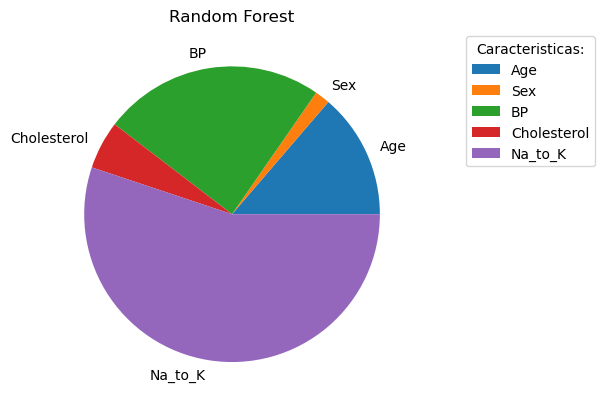

In [20]:
plot_feature_importance_Pie(BD_drugs, Random_Forest, feature_cols, "Random Forest")

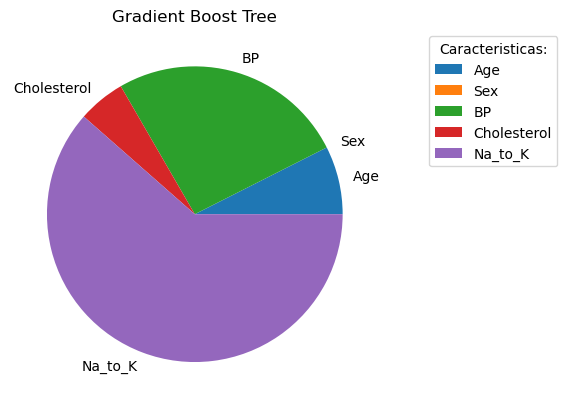

In [21]:
plot_feature_importance_Pie(BD_drugs, GradBoostTrees, feature_cols, "Gradient Boost Tree")

#### Gradient boosted trees con mas capaz (2,4)

In [25]:
for i in np.arange(2,5):
    GradBoostTrees = GradientBoostingClassifier(n_estimators = 200, max_depth=i)
    GradBoostTrees.fit(X_train, y_train)
    
    print("")
    print("PUNTUACIONES CON PROFUNDIDAD MAXIMA DE", i)
    # Score F1 para los grupos
    print("Training F1 Score:", GradBoostTrees.score(X_train, y_train))
    print("Testing F1 Score:",  GradBoostTrees.score(X_test, y_test))
    
    y_pred_GBT = Random_Forest.predict(X_test)
    print(classification_report(y_test, y_pred_GBT))


PUNTUACIONES CON PROFUNDIDAD MAXIMA DE 2
Training F1 Score: 1.0
Testing F1 Score: 0.9666666666666667
              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      0.75      0.86         4
       drugX       0.95      1.00      0.97        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.95        60
   macro avg       0.92      0.88      0.89        60
weighted avg       0.96      0.95      0.95        60


PUNTUACIONES CON PROFUNDIDAD MAXIMA DE 3
Training F1 Score: 1.0
Testing F1 Score: 0.9666666666666667
              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         4
       drugB       1.00      0.67      0.80         6
       drugC       1.00      0.75      0.86         4
       drugX       0.95      1.00      0.97        19
       drugY       1.00      1.00   

### AdaBoost Classifier

Desicion tree

In [28]:
from sklearn.ensemble import AdaBoostClassifier

# AdaBoost usa árboles de decisión como clasificar por default
ABC =AdaBoostClassifier(n_estimators=50, learning_rate=1)

#Entrenamiento del clasificador AdaBoost
Modelo = ABC.fit(X_train, y_train)
y_pred_ABC = Modelo.predict(X_test)

# Score F1 para los grupos
print("Training F1 Score:", Modelo.score(X_train, y_train))
print("Testing F1 Score:",  Modelo.score(X_test, y_test))

print(classification_report(y_test, y_pred_ABC))

Training F1 Score: 0.8428571428571429
Testing F1 Score: 0.8333333333333334
              precision    recall  f1-score   support

       drugA       0.40      1.00      0.57         4
       drugB       0.00      0.00      0.00         6
       drugC       0.00      0.00      0.00         4
       drugX       0.83      1.00      0.90        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.83        60
   macro avg       0.45      0.60      0.50        60
weighted avg       0.74      0.83      0.77        60



In [29]:
# Utilización de SVM como clasificador para AdaBoost
from sklearn.svm import SVC
SVCL = SVC(probability= True, kernel = "linear")
SVCP = SVC(probability= True, kernel = "poly")
SVCS = SVC(probability= True, kernel = "sigmoid")

SVM para AdaBoost (Linear)

In [34]:
# Creación de objeto de clasificación AdaBoost
ABC_SVCL = AdaBoostClassifier(n_estimators=200, estimator= SVCL, learning_rate=1)
M_ABC_SVCL = ABC_SVCL.fit(X_train, y_train)
y_pred_ABC_SVCL = M_ABC_SVCL.predict(X_test)

print("Reporte de clasificacion Linear")
print(classification_report(y_test, y_pred_ABC_SVCL))

Reporte de clasificacion Linear
              precision    recall  f1-score   support

       drugA       0.67      0.50      0.57         4
       drugB       0.43      0.50      0.46         6
       drugC       0.10      0.25      0.14         4
       drugX       0.92      0.63      0.75        19
       drugY       1.00      1.00      1.00        27

    accuracy                           0.75        60
   macro avg       0.62      0.58      0.59        60
weighted avg       0.84      0.75      0.78        60



SVM para AdaBoost (Polinomial)

In [36]:
# Creación de objeto de clasificación AdaBoost
ABC_SVCP = AdaBoostClassifier(n_estimators=200, estimator= SVCP, learning_rate=1)
M_ABC_SVCP = ABC_SVCP.fit(X_train, y_train)
y_pred_ABC_SVCP = M_ABC_SVCP.predict(X_test)

print("Reporte de clasificacion Polinomial")
print(classification_report(y_test, y_pred_ABC_SVCP))

Reporte de clasificacion Polinomial
              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         4
       drugB       0.50      0.33      0.40         6
       drugC       0.00      0.00      0.00         4
       drugX       0.00      0.00      0.00        19
       drugY       0.46      0.96      0.63        27

    accuracy                           0.47        60
   macro avg       0.19      0.26      0.21        60
weighted avg       0.26      0.47      0.32        60



SVM para AdaBoost (Sigmoidal)

In [40]:
# Creación de objeto de clasificación AdaBoost
ABC_SVCS = AdaBoostClassifier(n_estimators=200, estimator= SVCS, learning_rate=1)
M_ABC_SVCS = ABC_SVCS.fit(X_train, y_train)
y_pred_ABC_SVCS = M_ABC_SVCS.predict(X_test)

print("Reporte de clasificacion Sigmoidal")
print(classification_report(y_test, y_pred_ABC_SVCS))

Reporte de clasificacion Sigmoidal
              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         4
       drugB       0.00      0.00      0.00         6
       drugC       0.00      0.00      0.00         4
       drugX       0.00      0.00      0.00        19
       drugY       0.45      1.00      0.62        27

    accuracy                           0.45        60
   macro avg       0.09      0.20      0.12        60
weighted avg       0.20      0.45      0.28        60



## Explique cuál sería su recomendación para este caso.

Se realizaron diversos análisis tanto en Random Forest, Gradient Boosted y AdaBoost, lo cual permitió generar los siguientes análisis:
1. Se hizo una iteración permitiendo múltiples capaz y el modelo dejo de presentar cambio a partir de la cuarta capa máxima.
2. Se utilizó AdaBoost para ver posibles modelos sin usar Arboles de decisión (para estudio) y estos modelos solo empeoraron en la precisión.
3. El modelo con mejor rendimiento según el reporte de clasificación, F1 Score y comparándolo con otros modelos iguales de distintos parámetros se estimó que el Gradient boosted trees con 3 capaz máxima es el más preciso hasta ahora.
4. Presentando una puntuación del F1 score con una precisión del 95%, teniendo un 100% de aciertos en los entrenamientos, pero un 96.6% de aciertos en los valores de prueba.

## ¿Mejoró su poder predictivo al comparar sus resultados con los obtenidos mediante el árbol de decisión aplicado en la actividad del módulo previo? Explique.

Este empeoro en este caso posiblemente debido a dos motivos principales:

1. La muestra utilizada en la tarea anterior fue del 20% mientras que en esta se intentó utilizar una muestra del 30%.
2. La mayoría de modelos de Gradient boosted tree y Random Forest demostraron tener una mayor tendencia a los valores de precisión elevados a comparación que los modelos de la actividad anterior.
3. Los métodos SVM (linear, polinomial y sigmoidal) en este caso no son útiles para estos datos capturados y el modelo requerido, dado que el más elevado (linear) llego solo al 75% mientras que el resto únicamente llego a menos del 50%